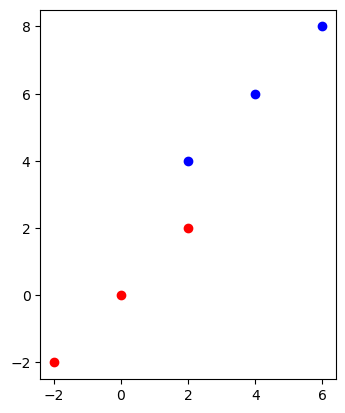

In [20]:
# 원본데이터 -> 평균 제거 -> PCA적용 ->변환된데이터
# 각 Feature의 평균을 빼서 데이터의 중심을 원점으로 옮기기
import matplotlib.pyplot as plt
import numpy as np
ax = plt.subplot(1,1,1,aspect='equal')
x = np.array([[2,4],[4,6],[6,8]])
ax.scatter(x[:,0], x[:,1],c='blue')
x -= x.mean(axis=0).astype(int)
ax.scatter(x[:,0], x[:,1], c='red')

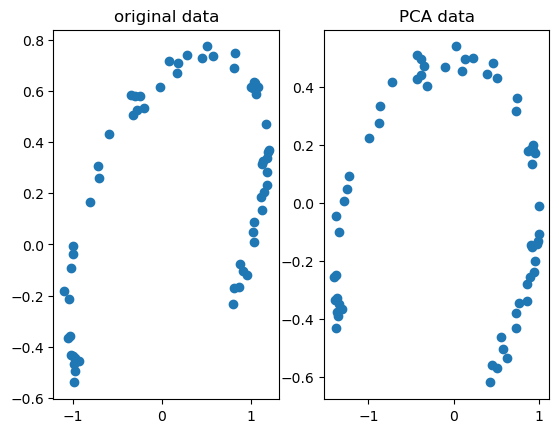

In [26]:
import numpy as np
np.random.seed(42)
m = 60
# 3차원데이터
w1, w2 = 0.1,0.3
noise = 0.1

angle = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m,3))

# 서로 약간 상관관계 있는 구조
X[:,0] = np.cos(angle) + np.sin(angle)/2 + noise*np.random.rand(m)
X[:,1] = np.sin(angle) * 0.7 + noise * np.random.rand(m)
X[:,2] = X[:,0] * w1 + X[:,1]*w2 + noise*np.random.rand(m)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

# 변환전 (X의 일부 차원만 시각화)
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1])
plt.title('original data')

plt.subplot(1,2,2)
plt.scatter(X2D[:,0],X2D[:,1])
plt.title('PCA data')

plt.show()


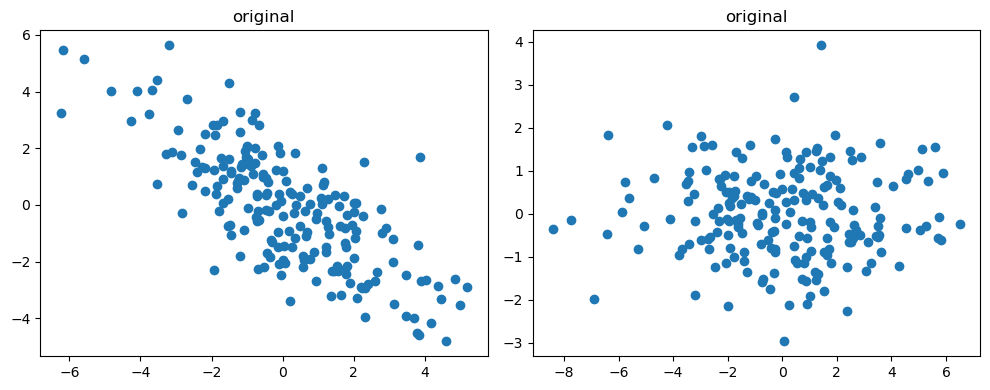

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
# 타원형 데이터 생성
m = 200
# 길게 늘어진 직선형태
X = np.random.randn(m,2)
X[:,0]*=3
# 회전(기울기)
theta = np.pi /4 # 45도 회전
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
X = X@rotation_matrix
#  PCA 적용
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].scatter(X[:,0], X[:,1])
ax[0].set_title('original')

ax[1].scatter(X2D[:,0], X2D[:,1])
ax[1].set_title('PCA')

plt.tight_layout()
plt.show()

In [36]:
# win 데이터셋
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)

#데이터 + 모델 조합  성능측정
#데이터(PCA변환) + 모델 조합  성능측정
X = wine.data
y = wine.target

In [68]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=2)),
])
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier,BaggingClassifier,StackingClassifier
from sklearn.model_selection import StratifiedKFold

models = {'sgd':SGDClassifier(random_state=42), 
          'randomF':RandomForestClassifier(random_state=42),
          'tree':DecisionTreeClassifier(random_state=42)
          }
for model_name,model in models.items():    
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    fold = StratifiedKFold(shuffle=True,random_state=42)
    y_predict = cross_val_predict(model,X_scaled,y,cv=fold)
    print(model_name)
    print(classification_report(y,y_predict))

sgd
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.96      0.97      0.97        71
           2       0.96      0.94      0.95        48

    accuracy                           0.97       178
   macro avg       0.97      0.97      0.97       178
weighted avg       0.97      0.97      0.97       178

randomF
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        59
           1       0.99      0.96      0.97        71
           2       0.96      1.00      0.98        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178

tree
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        59
           1       0.85      0.89      0.87        71
           2       0.92      0.92      0.92        48

   

In [94]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier,BaggingClassifier,StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
voting = VotingClassifier([
    ('sgd',SGDClassifier(random_state=42,loss='log_loss')),
    ('randomF',RandomForestClassifier(random_state=42)),    
    ('svc', SVC(random_state=42,probability=True,kernel='rbf'))
],voting = 'soft')
y_predict = cross_val_predict(voting,X_scaled,y,cv=fold)
print(classification_report(y,y_predict))

bagging = BaggingClassifier(voting,n_estimators=10,random_state=42)
y_predict = cross_val_predict(bagging,X_scaled,y,cv=fold)
print(classification_report(y,y_predict))

stacking = StackingClassifier([
    ('sgd',SGDClassifier(random_state=42,loss='log_loss')),
    ('randomF',RandomForestClassifier(random_state=42)),    
    ('svc', SVC(random_state=42,probability=True,kernel='rbf'))
],final_estimator=LogisticRegression(random_state=42))
y_predict = cross_val_predict(stacking,X_scaled,y,cv=fold)
print(classification_report(y,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.99      0.98        71
           2       0.98      0.96      0.97        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.99      0.98        71
           2       0.98      0.96      0.97        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.99      0.98        71
           2       0.98      0.96      0.97        48

    accuracy        

In [93]:
X.shape

(178, 13)

In [92]:
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=10)),
])
x_pipeline = pipeline.fit_transform(X)
stacking = StackingClassifier([
    ('sgd',SGDClassifier(random_state=42,loss='log_loss')),
    ('randomF',RandomForestClassifier(random_state=42)),    
    ('svc', SVC(random_state=42,probability=True,kernel='rbf'))
],final_estimator=LogisticRegression(random_state=42))
y_predict = cross_val_predict(stacking,x_pipeline,y,cv=fold)
print(classification_report(y,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.99      0.98        71
           2       0.98      0.96      0.97        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178



In [103]:
# n_compnents 찾기  누적분산
import numpy as np
pca = PCA(n_components=13)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
cumsum_variable =  np.cumsum(
    pca.explained_variance_ratio_
)
print(cumsum_variable)  # 95%이상이면 좋음, 90%이상이면 빠르게, 99%이상 -> 정보보존이 중요

np.argmax(cumsum_variable>=0.95)+1

[0.32853032 0.52534437 0.65218765 0.73007254 0.79975362 0.85582868
 0.90392525 0.92934163 0.9502528  0.96780032 0.9838928  0.99421865
 1.        ]


np.int64(9)

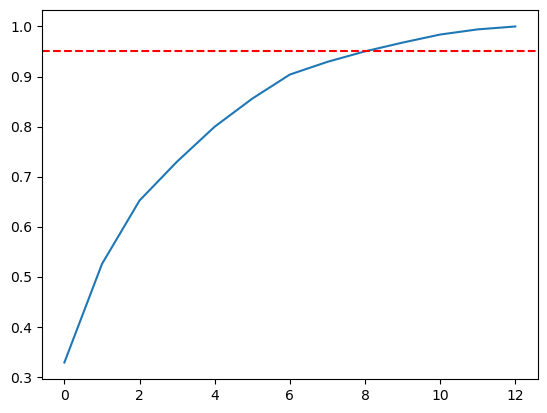

In [ ]:
# 시각적 엘보우... 급격히 증가후 완만해지는 구간
import matplotlib.pyplot as plt
plt.plot(cumsum_variable)
plt.axhline(y=0.95,linestyle='--',c='red')

In [ ]:
# 자동으로 찾기
# n_compnents 찾기  누적분산
import numpy as np
pca = PCA(n_components=0.95)  # 95% 분산을 설명하는 최소 component 자동선택
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
print(pca.n_components_)

9


In [ ]:
# 시각화